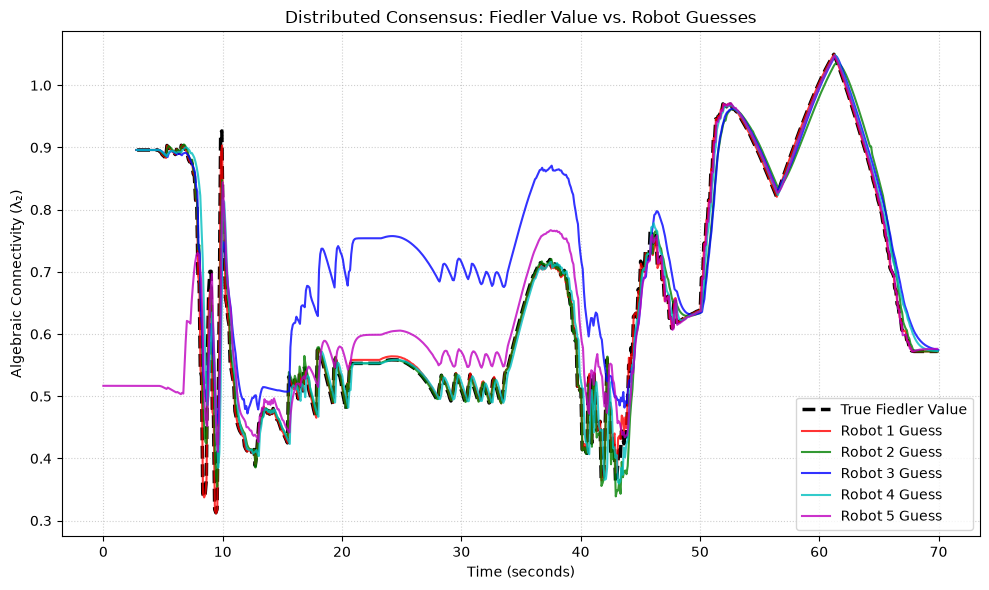

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader

# Replace with your bag folder name
BAG_PATH = Path('fiedler_experiment_01')

data = {
    '/fiedler_value': {'t': [], 'val': []},
    '/robot1/fiedler_guess': {'t': [], 'val': []},
    '/robot2/fiedler_guess': {'t': [], 'val': []},
    '/robot3/fiedler_guess': {'t': [], 'val': []},
    '/robot4/fiedler_guess': {'t': [], 'val': []},
    '/robot5/fiedler_guess': {'t': [], 'val': []},
}

# Open the bag using AnyReader (expects a list of Path objects)
with AnyReader([BAG_PATH]) as reader:
    for connection, timestamp, rawdata in reader.messages():
        if connection.topic in data:
            # Deserialize directly using the reader's built-in helper
            msg = reader.deserialize(rawdata, connection.msgtype)
            
            # Convert timestamp from nanoseconds to seconds relative to start
            data[connection.topic]['t'].append(timestamp / 1e9)
            data[connection.topic]['val'].append(msg.data)

# Normalize timestamps to start at t=0
start_time = min(df['t'][0] for df in data.values() if df['t'])
for topic in data:
    data[topic]['t'] = [t - start_time for t in data[topic]['t']]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data['/fiedler_value']['t'], data['/fiedler_value']['val'], 
         'k--', linewidth=2.5, label='True Fiedler Value')

colors = ['r', 'g', 'b', 'c', 'm']
for i in range(1, 6):
    topic = f'/robot{i}/fiedler_guess'
    plt.plot(data[topic]['t'], data[topic]['val'], 
             color=colors[i-1], alpha=0.8, label=f'Robot {i} Guess')

plt.title('Distributed Consensus: Fiedler Value vs. Robot Guesses')
plt.xlabel('Time (seconds)')
plt.ylabel('Algebraic Connectivity (λ₂)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('fiedler_consensus_plot.png', dpi=300)
plt.show()